# IoT-23 Dataset

This notebook:
- downloads selected IoT-23 v2 Zeek connection logs from the official site
- parses the labeled files into one table
- checks columns, file sizes, missing values, and class balance
- creates a balanced binary dataset for the project

One larger benign capture is capped so the balanced dataset can target at least 200K total rows while still downloading from the official source.


In [5]:
from pathlib import Path
from urllib.parse import urljoin
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, auc, confusion_matrix, f1_score, precision_score, recall_score, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from tqdm.auto import tqdm
from bs4 import BeautifulSoup
from IPython.display import display

try:
    from google.colab import drive
except ImportError:
    drive = None

BASE_URL = "https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset-v2/"
DRIVE_DIR = Path("/content/drive/MyDrive/flow_guard/iot23_data")

if drive is not None:
    drive.mount("/content/drive", force_remount=False)
    OUT_DIR = DRIVE_DIR
else:
    OUT_DIR = Path("iot23_data")

OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2
ROW_LIMITS = {
    "CTU-Honeypot-Capture-7-1": 90000,
    "CTU-IoT-Malware-Capture-1-1": 40000,
}

CAPTURES = {
    "benign": [
        "CTU-Honeypot-Capture-4-1",
        "CTU-Honeypot-Capture-5-1",
        "CTU-Honeypot-Capture-7-1",
        "CTU-Honeypot-Capture-7-2",
        "CTU-Honeypot-Capture-7-3",
        "CTU-Honeypot-Capture-7-4",
        "CTU-Honeypot-Capture-7-5",
        "CTU-Honeypot-Capture-7-6",
    ],
    "malicious": [
        "CTU-IoT-Malware-Capture-1-1",
        "CTU-IoT-Malware-Capture-20-1",
        "CTU-IoT-Malware-Capture-42-1",
        "CTU-IoT-Malware-Capture-8-1",
        "CTU-IoT-Malware-Capture-34-1",
        "CTU-IoT-Malware-Capture-3-1",
    ],
}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
splitter = re.compile(r"\t| {2,}")


def split_zeek(text):
    return [part for part in splitter.split(text.rstrip("\n")) if part]


def get_conn_log_url(capture):
    page = requests.get(urljoin(BASE_URL, f"{capture}/"), timeout=60)
    page.raise_for_status()
    soup = BeautifulSoup(page.text, "html.parser")

    for a in soup.select("a[href$='.labeled']"):
        href = a.get("href", "")
        if "zeek-conn" in href:
            return urljoin(page.url, href)

    raise FileNotFoundError(capture)


def download(url, dst):
    if dst.exists():
        return dst

    response = requests.get(url, stream=True, timeout=300)
    response.raise_for_status()
    total = int(response.headers.get("content-length", 0))

    with open(dst, "wb") as f, tqdm(
        total=total,
        unit="B",
        unit_scale=True,
        desc=dst.name,
        leave=False,
    ) as bar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if not chunk:
                continue

            f.write(chunk)
            bar.update(len(chunk))

    return dst


In [7]:
def read_conn_log(path, capture, default_label, max_rows=None):
    fields = None
    rows = []

    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            if line.startswith("#fields"):
                fields = split_zeek(line)[1:]
                continue

            if not line.strip() or line.startswith("#"):
                continue

            parts = split_zeek(line)
            if len(parts) != len(fields):
                continue

            rows.append(parts)

            if max_rows and len(rows) >= max_rows:
                break

    df = pd.DataFrame(rows, columns=fields)

    if "label" not in df.columns:
        df["label"] = default_label

    if "detailed-label" not in df.columns:
        df["detailed-label"] = df["label"]

    df["capture"] = capture
    df["target"] = np.where(df["label"].str.lower().eq("benign"), "benign", "malicious")
    return df


In [8]:
frames = []
capture_rows = []
capture_list = [
    (default_label, capture)
    for default_label, capture_names in CAPTURES.items()
    for capture in capture_names
]

for default_label, capture in tqdm(capture_list, desc="Loading captures"):
    url = get_conn_log_url(capture)
    path = download(url, OUT_DIR / url.split("/")[-1])
    df = read_conn_log(path, capture, default_label, ROW_LIMITS.get(capture))

    frames.append(df)
    capture_rows.append(
        {
            "capture": capture,
            "file": path.name,
            "size_mb": round(path.stat().st_size / 1_048_576, 2),
            "rows": len(df),
            "benign_rows": int((df["target"] == "benign").sum()),
            "malicious_rows": int((df["target"] == "malicious").sum()),
        }
    )

raw_df = pd.concat(frames, ignore_index=True)
capture_summary = pd.DataFrame(capture_rows).sort_values("capture").reset_index(drop=True)

display(capture_summary)
raw_df.head()


Loading captures:   0%|          | 0/14 [00:00<?, ?it/s]

,capture,file,size_mb,rows,benign_rows,malicious_rows
0,CTU-Honeypot-Capture-4-1,2018-10-25-14-06-32-192.168.1.132-zeek-conn.lo...,0.06,452,452,0
1,CTU-Honeypot-Capture-5-1,2018-09-21-11-40-22-192.168.2.3-zeek-conn-log....,0.17,1374,1374,0
2,CTU-Honeypot-Capture-7-1,2019-07-03-15-15-47-192.168.1.158-zeek-conn-lo...,1222.38,90000,90000,0
3,CTU-Honeypot-Capture-7-2,2019-07-03-16-41-09-192.168.1.158-zeek-conn-lo...,0.01,52,52,0
4,CTU-Honeypot-Capture-7-3,2019-07-04-16-41-10-192.168.1.158-zeek-conn-lo...,0.00,26,26,0
5,CTU-Honeypot-Capture-7-4,2019-07-05-16-41-14-192.168.1.158-zeek-conn-lo...,0.01,49,49,0
6,CTU-Honeypot-Capture-7-5,2019-07-06-16-41-17-192.168.1.158-zeek-conn-lo...,0.01,53,53,0
7,CTU-Honeypot-Capture-7-6,2019-07-07-16-41-19-192.168.1.158-zeek-conn-lo...,0.01,52,52,0
8,CTU-IoT-Malware-Capture-1-1,2018-05-09-17-30-31-192.168.100.103-zeek-conn-...,137.59,40000,17749,22251
9,CTU-IoT-Malware-Capture-20-1,2018-10-02-13-12-30-192.168.100.103-zeek-conn-...,0.40,3209,3193,16


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label,capture,target,detailed_label
0,1540469302.538640,CGm6jB4dXK71ZDWUDh,192.168.1.132,58687,216.239.35.4,123,udp,-,0.114184,48,...,1,76,1,76,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN
1,1540469197.400159,CnaDAG3n5r8eiG4su2,192.168.1.132,1900,239.255.255.250,1900,udp,-,160.367579,7536,...,24,8208,0,0,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN
2,1540469385.734089,CUrxU238nt0m6yTgKf,192.168.1.132,32893,216.239.35.8,123,udp,-,0.016986,48,...,1,76,1,76,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN
3,1540469831.302625,CGQf8t1kjdxB5PHXL4,192.168.1.132,53395,2.16.60.82,443,tcp,-,0.003497,0,...,5,212,3,144,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN
4,1540469831.265405,CUo9DH2QDnCaBIGjkg,192.168.1.132,52801,192.168.1.1,53,udp,dns,0.036724,34,...,1,62,1,339,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN


In [9]:
id_cols = {"label", "detailed-label", "target", "capture"}
feature_cols = [c for c in raw_df.columns if c not in id_cols]

dataset_note = pd.DataFrame(
    {
        "feature_count": [len(feature_cols)],
        "sample_count": [len(raw_df)],
        "file_count": [len(capture_summary)],
    }
)

missing_source = raw_df[feature_cols].mask(raw_df[feature_cols].isin(["-", "(empty)"]))

missing = (
    missing_source.isna()
    .sum()
    .sort_values(ascending=False)
    .rename_axis("column")
    .reset_index(name="missing_values")
)

print("Dataset note")
display(dataset_note)

print("Raw class distribution")
display(raw_df["target"].value_counts().rename_axis("target").reset_index(name="rows"))

print("Columns")
display(pd.Series(raw_df.columns, name="column").to_frame())

print("Top missing-value columns")
display(missing.head(10))


Dataset note


,feature_count,sample_count,file_count
0,22,329344,14


Raw class distribution


,target,rows
0,malicious,203284
1,benign,126060


Columns


,column
0,ts
1,uid
2,id.orig_h
3,id.orig_p
4,id.resp_h
5,id.resp_p
6,proto
7,service
8,duration
9,orig_bytes


Top missing-value columns


,column,missing_values
0,local_resp,329344
1,local_orig,329344
2,tunnel_parents,329344
3,service,317634
4,detailed_label,307093
5,orig_bytes,220919
6,resp_bytes,220919
7,duration,220919
8,history,2375
9,id.resp_h,0


In [10]:
def balance_split(df):
    n = df["target"].value_counts().min()
    return (
        df.groupby("target", group_keys=False)
        .sample(n=n, random_state=SEED)
        .reset_index(drop=True)
    )

capture_sets = {
    "train": [
        "CTU-Honeypot-Capture-7-1",
        "CTU-IoT-Malware-Capture-3-1",
        "CTU-IoT-Malware-Capture-34-1",
        "CTU-IoT-Malware-Capture-42-1",
        "CTU-IoT-Malware-Capture-20-1",
    ],
    "val": ["CTU-IoT-Malware-Capture-1-1"],
    "test": [
        "CTU-IoT-Malware-Capture-8-1",
        "CTU-Honeypot-Capture-5-1",
        "CTU-Honeypot-Capture-4-1",
        "CTU-Honeypot-Capture-7-5",
        "CTU-Honeypot-Capture-7-6",
        "CTU-Honeypot-Capture-7-2",
        "CTU-Honeypot-Capture-7-4",
        "CTU-Honeypot-Capture-7-3",
    ],
}

assigned = sorted(sum(capture_sets.values(), []))
expected = sorted(sum(CAPTURES.values(), []))
assert assigned == expected

train_raw_df = raw_df[raw_df["capture"].isin(capture_sets["train"])]
val_df = raw_df[raw_df["capture"].isin(capture_sets["val"])].reset_index(drop=True)
test_df = raw_df[raw_df["capture"].isin(capture_sets["test"])].reset_index(drop=True)
train_df = balance_split(train_raw_df)
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

train_df.to_csv(OUT_DIR / "train.csv", index=False)
val_df.to_csv(OUT_DIR / "val.csv", index=False)
test_df.to_csv(OUT_DIR / "test.csv", index=False)
all_df.to_csv(OUT_DIR / "all.csv", index=False)
capture_summary.to_csv(OUT_DIR / "iot23_capture_summary.csv", index=False)

final_note = pd.DataFrame(
    {
        "feature_count": [len(feature_cols)],
        "sample_count": [len(all_df)],
        "label_distribution": [all_df["target"].value_counts().to_dict()],
    }
)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "labels": train_df["target"].value_counts().to_dict()},
        {"split": "val", "rows": len(val_df), "labels": val_df["target"].value_counts().to_dict()},
        {"split": "test", "rows": len(test_df), "labels": test_df["target"].value_counts().to_dict()},
    ]
)

print("Balanced train distribution")
display(train_df["target"].value_counts().rename_axis("target").reset_index(name="rows"))

print("Capture split")
display(pd.DataFrame({"split": list(capture_sets), "captures": [", ".join(capture_sets[s]) for s in capture_sets]}))

print("Split summary")
display(split_summary)

print("Final note")
display(final_note)

print("Saved files")
print(OUT_DIR / "train.csv")
print(OUT_DIR / "val.csv")
print(OUT_DIR / "test.csv")
print(OUT_DIR / "all.csv")
print(OUT_DIR / "iot23_capture_summary.csv")


Balanced train distribution


,target,rows
0,benign,104072
1,malicious,104072


Capture split


,split,captures
0,train,"CTU-Honeypot-Capture-7-1, CTU-IoT-Malware-Capt..."
1,val,CTU-IoT-Malware-Capture-1-1
2,test,"CTU-IoT-Malware-Capture-8-1, CTU-Honeypot-Capt..."


Split summary


,split,rows,labels
0,train,208144,"{'benign': 104072, 'malicious': 104072}"
1,val,40000,"{'malicious': 22251, 'benign': 17749}"
2,test,12461,"{'malicious': 8222, 'benign': 4239}"


Final note


,feature_count,sample_count,label_distribution
0,22,260605,"{'malicious': 134545, 'benign': 126060}"


Saved files
/content/drive/MyDrive/flow_guard/iot23_data/train.csv
/content/drive/MyDrive/flow_guard/iot23_data/val.csv
/content/drive/MyDrive/flow_guard/iot23_data/test.csv
/content/drive/MyDrive/flow_guard/iot23_data/all.csv
/content/drive/MyDrive/flow_guard/iot23_data/iot23_capture_summary.csv


In [11]:
num_cols = [
    "id.orig_p", "id.resp_p", "duration", "orig_bytes", "resp_bytes",
    "missed_bytes", "orig_pkts", "orig_ip_bytes", "resp_pkts", "resp_ip_bytes",
]
bool_cols = [
    col for col in ["local_orig", "local_resp"]
    if train_df[col].replace({"-": np.nan, "(empty)": np.nan}).notna().any()
]
cat_cols = ["proto", "service", "conn_state", "history"]
model_cols = num_cols + bool_cols + cat_cols

def prepare_split(df):
    clean = df[model_cols + ["target"]].copy()
    clean = clean.mask(clean.isin(["-", "(empty)"]))

    for col in bool_cols:
        clean[col] = clean[col].map({"T": 1, "F": 0})

    for col in num_cols + bool_cols:
        clean[col] = pd.to_numeric(clean[col], errors="coerce")

    return clean

train_prep = prepare_split(train_df)
val_prep = prepare_split(val_df)
test_prep = prepare_split(test_df)

X_train_df = train_prep[model_cols]
X_val_df = val_prep[model_cols]
X_test_df = test_prep[model_cols]
y_train = train_prep["target"]
y_val = val_prep["target"]
y_test = test_prep["target"]

def make_preprocessor():
    return ColumnTransformer(
        [
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols + bool_cols),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
        ]
    )

preprocessor = make_preprocessor()

X_train = preprocessor.fit_transform(X_train_df)
X_val = preprocessor.transform(X_val_df)
X_test = preprocessor.transform(X_test_df)

prep_summary = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [len(X_train_df), len(X_val_df), len(X_test_df)],
        "input_features": [len(model_cols)] * 3,
        "output_features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
    }
)

print("Preprocessing summary")
display(prep_summary)


/tmp/ipykernel_24675/3456560315.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if train_df[col].replace({"-": np.nan, "(empty)": np.nan}).notna().any()


Preprocessing summary


,split,rows,input_features,output_features
0,train,208144,14,127
1,val,40000,14,127
2,test,12461,14,127


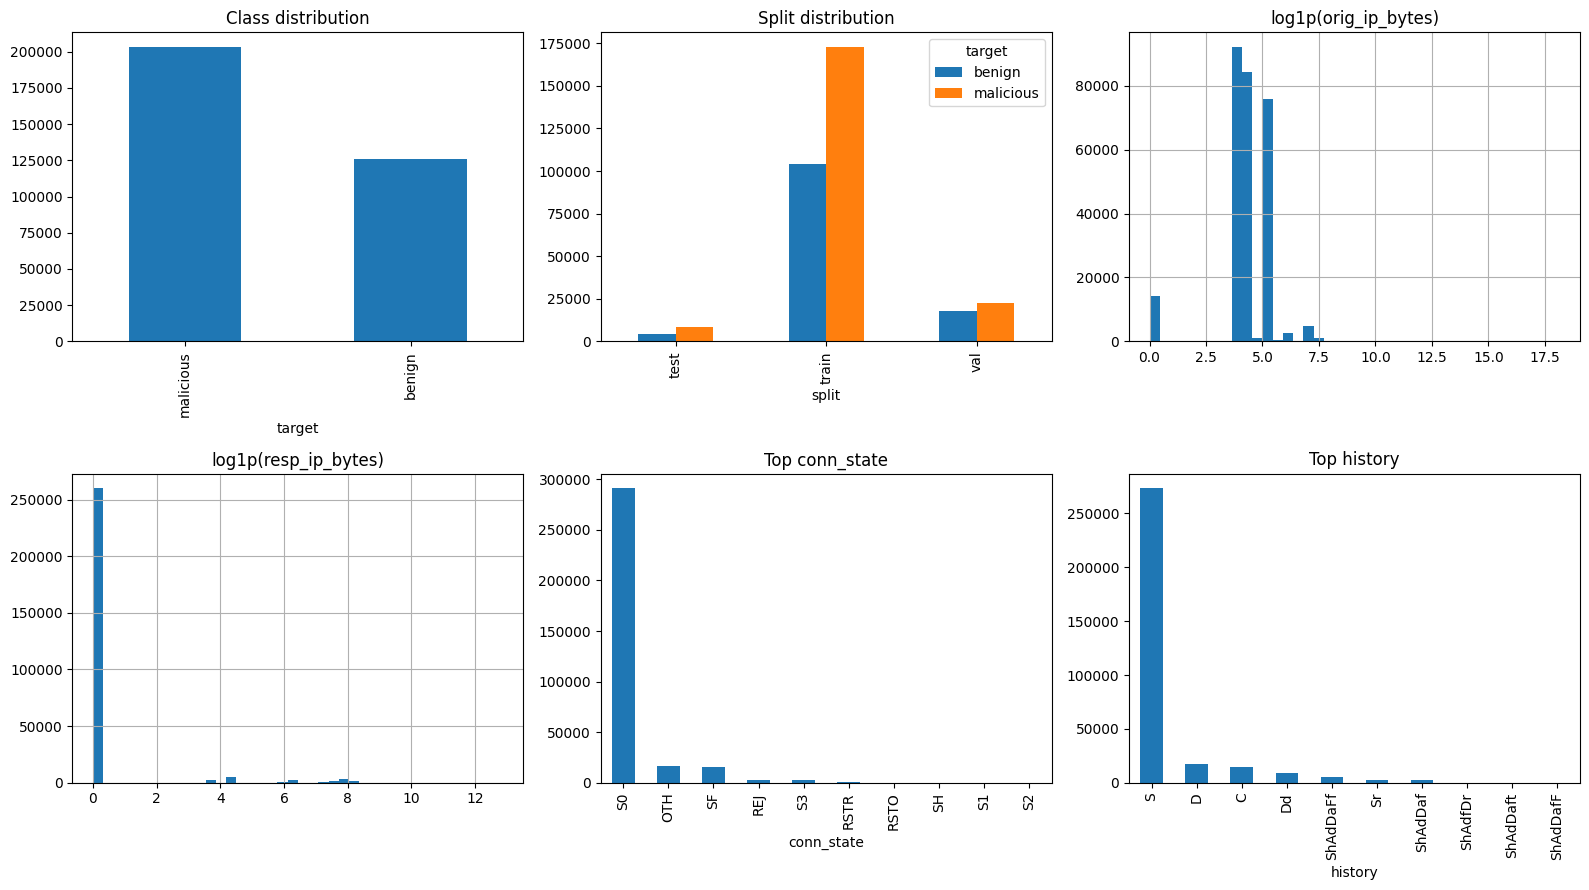

Missing percentage


,feature,missing_pct
0,service,96.44
1,orig_bytes,67.08
2,duration,67.08
3,resp_bytes,67.08
4,history,0.72
5,orig_pkts,0.00
6,orig_ip_bytes,0.00
7,resp_ip_bytes,0.00
8,resp_pkts,0.00
9,proto,0.00


Outlier percentage (IQR)


,feature,outlier_pct
0,duration,25.85
1,orig_bytes,18.01
2,resp_bytes,16.93
3,resp_ip_bytes,6.56
4,resp_pkts,6.56
5,orig_ip_bytes,2.89
6,orig_pkts,2.82


In [12]:
analysis_num_cols = ["duration", "orig_bytes", "resp_bytes", "orig_pkts", "orig_ip_bytes", "resp_pkts", "resp_ip_bytes"]
analysis_cat_cols = ["proto", "service", "conn_state", "history"]

analysis_df = raw_df[analysis_num_cols + analysis_cat_cols + ["target", "capture"]].copy()
analysis_df = analysis_df.mask(analysis_df.isin(["-", "(empty)"]))

for col in analysis_num_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

missing_pct = (
    analysis_df[analysis_num_cols + analysis_cat_cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename_axis("feature")
    .reset_index(name="missing_pct")
)

outlier_rows = []
for col in analysis_num_cols:
    s = analysis_df[col].dropna()
    if len(s) < 4:
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_rows.append(
        {
            "feature": col,
            "outlier_pct": round(((s < lower) | (s > upper)).mean() * 100, 2),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False).reset_index(drop=True)

split_counts = pd.concat(
    [
        train_raw_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
).groupby(["split", "target"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

analysis_df["target"].value_counts().plot(kind="bar", ax=axes[0, 0], title="Class distribution")
split_counts.plot(kind="bar", ax=axes[0, 1], title="Split distribution")
np.log1p(train_raw_df["orig_ip_bytes"].replace({"-": np.nan, "(empty)": np.nan}).astype(float)).dropna().hist(bins=40, ax=axes[0, 2])
axes[0, 2].set_title("log1p(orig_ip_bytes)")
np.log1p(train_raw_df["resp_ip_bytes"].replace({"-": np.nan, "(empty)": np.nan}).astype(float)).dropna().hist(bins=40, ax=axes[1, 0])
axes[1, 0].set_title("log1p(resp_ip_bytes)")
analysis_df["conn_state"].value_counts().head(10).plot(kind="bar", ax=axes[1, 1], title="Top conn_state")
analysis_df["history"].value_counts().head(10).plot(kind="bar", ax=axes[1, 2], title="Top history")
plt.tight_layout()
plt.show()

print("Missing percentage")
display(missing_pct)

print("Outlier percentage (IQR)")
display(outlier_summary)


In [13]:
zeror_class = train_raw_df["target"].mode()[0]
val_pred = pd.Series(zeror_class, index=val_df.index)

zeror_summary = pd.DataFrame(
    {
        "baseline": ["ZeroR"],
        "predicted_class": [zeror_class],
        "accuracy": [accuracy_score(val_df["target"], val_pred)],
        "precision": [precision_score(val_df["target"], val_pred, pos_label="malicious", zero_division=0)],
        "recall": [recall_score(val_df["target"], val_pred, pos_label="malicious", zero_division=0)],
        "f1": [f1_score(val_df["target"], val_pred, pos_label="malicious", zero_division=0)],
    }
)

print("ZeroR on validation")
display(zeror_summary)


ZeroR on validation


,baseline,predicted_class,accuracy,precision,recall,f1
0,ZeroR,malicious,0.556275,0.556275,1.0,0.71488


In [14]:
lr_params = {
    "C": 1.0,
    "penalty": "l2",
    "solver": "lbfgs",
    "max_iter": 1000,
}

lr = LogisticRegression(**lr_params, random_state=SEED)
lr.fit(X_train, y_train)

lr_train_pred = lr.predict(X_train)
lr_val_pred = lr.predict(X_val)

lr_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "accuracy": accuracy_score(y_train, lr_train_pred),
            "precision": precision_score(y_train, lr_train_pred, pos_label="malicious", zero_division=0),
            "recall": recall_score(y_train, lr_train_pred, pos_label="malicious", zero_division=0),
            "f1": f1_score(y_train, lr_train_pred, pos_label="malicious", zero_division=0),
        },
        {
            "split": "val",
            "accuracy": accuracy_score(y_val, lr_val_pred),
            "precision": precision_score(y_val, lr_val_pred, pos_label="malicious", zero_division=0),
            "recall": recall_score(y_val, lr_val_pred, pos_label="malicious", zero_division=0),
            "f1": f1_score(y_val, lr_val_pred, pos_label="malicious", zero_division=0),
        },
    ]
)

print("Logistic Regression")
print(lr_params)
display(lr_summary)


Logistic Regression
{'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1000}


,split,accuracy,precision,recall,f1
0,train,0.994393,0.989590,0.999299,0.994421
1,val,0.946775,0.925772,0.983147,0.953597


In [15]:
svm_params = {
    "C": 1.0,
    "loss": "squared_hinge",
    "max_iter": 5000,
}

svm = LinearSVC(**svm_params, random_state=SEED)
svm.fit(X_train, y_train)

svm_train_pred = svm.predict(X_train)
svm_val_pred = svm.predict(X_val)

svm_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "accuracy": accuracy_score(y_train, svm_train_pred),
            "precision": precision_score(y_train, svm_train_pred, pos_label="malicious", zero_division=0),
            "recall": recall_score(y_train, svm_train_pred, pos_label="malicious", zero_division=0),
            "f1": f1_score(y_train, svm_train_pred, pos_label="malicious", zero_division=0),
        },
        {
            "split": "val",
            "accuracy": accuracy_score(y_val, svm_val_pred),
            "precision": precision_score(y_val, svm_val_pred, pos_label="malicious", zero_division=0),
            "recall": recall_score(y_val, svm_val_pred, pos_label="malicious", zero_division=0),
            "f1": f1_score(y_val, svm_val_pred, pos_label="malicious", zero_division=0),
        },
    ]
)

print("Linear SVM")
print(svm_params)
display(svm_summary)


Linear SVM
{'C': 1.0, 'loss': 'squared_hinge', 'max_iter': 5000}


,split,accuracy,precision,recall,f1
0,train,0.994571,0.989855,0.999385,0.994597
1,val,0.946775,0.925772,0.983147,0.953597


In [16]:
rf_params = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "n_jobs": -1,
}

rf = RandomForestClassifier(**rf_params, random_state=SEED)
rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "accuracy": accuracy_score(y_train, rf_train_pred),
            "precision": precision_score(y_train, rf_train_pred, pos_label="malicious", zero_division=0),
            "recall": recall_score(y_train, rf_train_pred, pos_label="malicious", zero_division=0),
            "f1": f1_score(y_train, rf_train_pred, pos_label="malicious", zero_division=0),
        },
        {
            "split": "val",
            "accuracy": accuracy_score(y_val, rf_val_pred),
            "precision": precision_score(y_val, rf_val_pred, pos_label="malicious", zero_division=0),
            "recall": recall_score(y_val, rf_val_pred, pos_label="malicious", zero_division=0),
            "f1": f1_score(y_val, rf_val_pred, pos_label="malicious", zero_division=0),
        },
    ]
)

print("Random Forest")
print(rf_params)
display(rf_summary)


Random Forest
{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'n_jobs': -1}


,split,accuracy,precision,recall,f1
0,train,1.00000,1.000000,1.0000,1.00000
1,val,0.92715,0.924933,0.9458,0.93525


In [17]:
val_comparison = pd.concat(
    [
        zeror_summary.assign(model="ZeroR", split="val").drop(columns=["baseline", "predicted_class"], errors="ignore"),
        lr_summary.assign(model="LogisticRegression"),
        svm_summary.assign(model="LinearSVM"),
        rf_summary.assign(model="RandomForest"),
    ],
    ignore_index=True,
)

val_comparison = (
    val_comparison[val_comparison["split"] == "val"]
    [["model", "accuracy", "precision", "recall", "f1"]]
    .sort_values(["f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

best_model = val_comparison.loc[0, "model"]
val_comparison.to_csv(OUT_DIR / "model_compare.csv", index=False)

print("Validation comparison")
display(val_comparison)
print("Best model:", best_model)
print(OUT_DIR / "model_compare.csv")


Validation comparison


,model,accuracy,precision,recall,f1
0,LogisticRegression,0.946775,0.925772,0.983147,0.953597
1,LinearSVM,0.946775,0.925772,0.983147,0.953597
2,RandomForest,0.927150,0.924933,0.945800,0.935250
3,ZeroR,0.556275,0.556275,1.000000,0.714880


Best model: LogisticRegression
/content/drive/MyDrive/flow_guard/iot23_data/model_compare.csv


In [18]:
models = {
    "ZeroR": (pd.Series(zeror_class, index=y_test.index), None),
    "LogisticRegression": (lr.predict(X_test), lr),
    "LinearSVM": (svm.predict(X_test), svm),
    "RandomForest": (rf.predict(X_test), rf),
}

test_pred, final_model = models[best_model]

test_summary = pd.DataFrame(
    {
        "model": [best_model],
        "accuracy": [accuracy_score(y_test, test_pred)],
        "precision": [precision_score(y_test, test_pred, pos_label="malicious", zero_division=0)],
        "recall": [recall_score(y_test, test_pred, pos_label="malicious", zero_division=0)],
        "f1": [f1_score(y_test, test_pred, pos_label="malicious", zero_division=0)],
    }
)

test_summary.to_csv(OUT_DIR / "test_results.csv", index=False)

print("Final test")
display(test_summary)
print(OUT_DIR / "test_results.csv")


Final test


,model,accuracy,precision,recall,f1
0,LogisticRegression,0.966134,0.95118,1.0,0.974979


/content/drive/MyDrive/flow_guard/iot23_data/test_results.csv


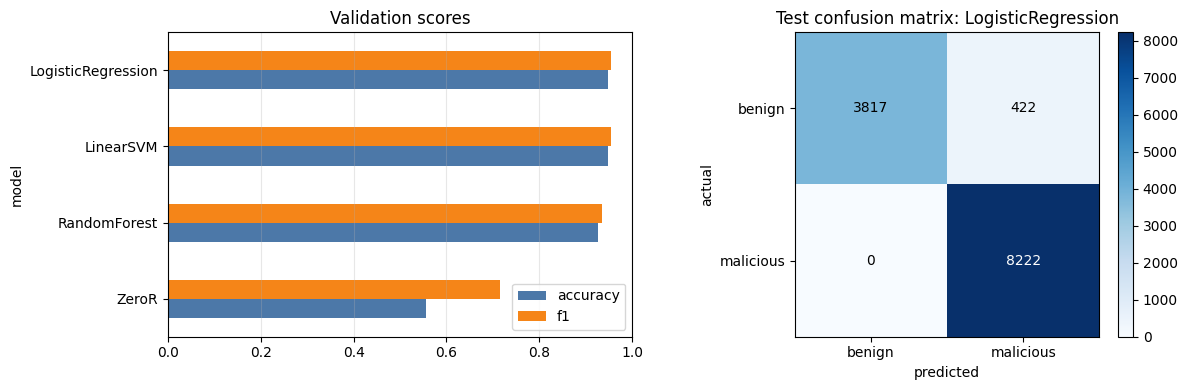

,pred_benign,pred_malicious
true_benign,3817,422
true_malicious,0,8222


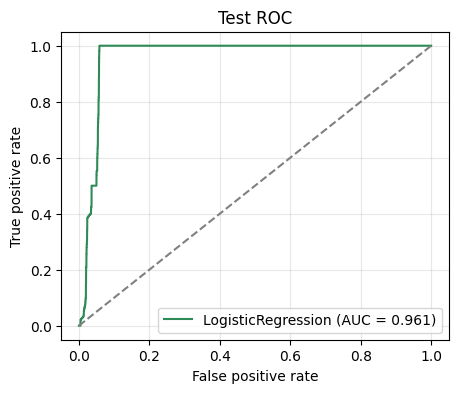

Discussion draft
- Best validation model: LogisticRegression.
- Validation F1 = 0.954; test F1 = 0.975.
- Training and validation stay close, which suggests the model is learning patterns that transfer to new captures.
- Test performance matches or beats validation, so the model generalizes well on the chosen test captures.
- Precision and recall are close, so false positives and false negatives are fairly balanced.
- ROC AUC = 0.961, which shows how well the model ranks malicious flows above benign ones.
/content/drive/MyDrive/flow_guard/iot23_data/discussion.txt


In [19]:
labels = ["benign", "malicious"]
cm = pd.DataFrame(
    confusion_matrix(y_test, test_pred, labels=labels),
    index=[f"true_{label}" for label in labels],
    columns=[f"pred_{label}" for label in labels],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(
    val_comparison.sort_values("f1")
    .set_index("model")[["accuracy", "f1"]]
    .plot(kind="barh", ax=axes[0], color=["#4C78A8", "#F58518"])
)
axes[0].set_title("Validation scores")
axes[0].set_xlim(0, 1)
axes[0].grid(axis="x", alpha=0.3)

im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_title(f"Test confusion matrix: {best_model}")
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels)
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("actual")

for i in range(len(labels)):
    for j in range(len(labels)):
        value = cm.iloc[i, j]
        color = "white" if value > cm.to_numpy().max() / 2 else "black"
        axes[1].text(j, i, value, ha="center", va="center", color=color)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
display(cm)

roc_auc = np.nan
if best_model == "LogisticRegression":
    test_score = final_model.predict_proba(X_test)[:, 1]
elif best_model == "LinearSVM":
    test_score = final_model.decision_function(X_test)
elif best_model == "RandomForest":
    test_score = final_model.predict_proba(X_test)[:, 1]
else:
    test_score = None

if test_score is not None:
    y_test_bin = y_test.eq("malicious").astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, test_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"{best_model} (AUC = {roc_auc:.3f})", color="#2E8B57")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Test ROC")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("ROC not available for ZeroR.")

summary_map = {
    "LogisticRegression": lr_summary,
    "LinearSVM": svm_summary,
    "RandomForest": rf_summary,
}
val_row = val_comparison.set_index("model").loc[best_model]
test_row = test_summary.iloc[0]
train_f1 = np.nan

if best_model in summary_map:
    train_f1 = summary_map[best_model].set_index("split").loc["train", "f1"]

if np.isnan(train_f1):
    fit_note = "This is a baseline model, so there is no training fit gap to inspect."
elif train_f1 - val_row["f1"] > 0.05:
    fit_note = "Training is much stronger than validation, which points to overfitting on the training captures."
elif val_row["f1"] < 0.7:
    fit_note = "Validation is still weak, which suggests underfitting or features that are not strong enough yet."
else:
    fit_note = "Training and validation stay close, which suggests the model is learning patterns that transfer to new captures."

if val_row["f1"] - test_row["f1"] > 0.05:
    generalization_note = "Test performance drops on unseen test captures, so generalization is still limited."
elif test_row["f1"] >= val_row["f1"]:
    generalization_note = "Test performance matches or beats validation, so the model generalizes well on the chosen test captures."
else:
    generalization_note = "Test performance is slightly below validation, which is normal on unseen captures."

if test_row["recall"] > test_row["precision"] + 0.05:
    error_note = "Recall is higher than precision, so the model catches more attacks but raises more false alarms."
elif test_row["precision"] > test_row["recall"] + 0.05:
    error_note = "Precision is higher than recall, so the model is conservative and misses more attacks."
else:
    error_note = "Precision and recall are close, so false positives and false negatives are fairly balanced."

discussion = [
    f"Best validation model: {best_model}.",
    f"Validation F1 = {val_row['f1']:.3f}; test F1 = {test_row['f1']:.3f}.",
    fit_note,
    generalization_note,
    error_note,
]

if not np.isnan(roc_auc):
    discussion.append(f"ROC AUC = {roc_auc:.3f}, which shows how well the model ranks malicious flows above benign ones.")

discussion_path = OUT_DIR / "discussion.txt"
discussion_path.write_text("\n".join(f"- {line}" for line in discussion), encoding="utf-8")

print("Discussion draft")
for line in discussion:
    print(f"- {line}")
print(discussion_path)


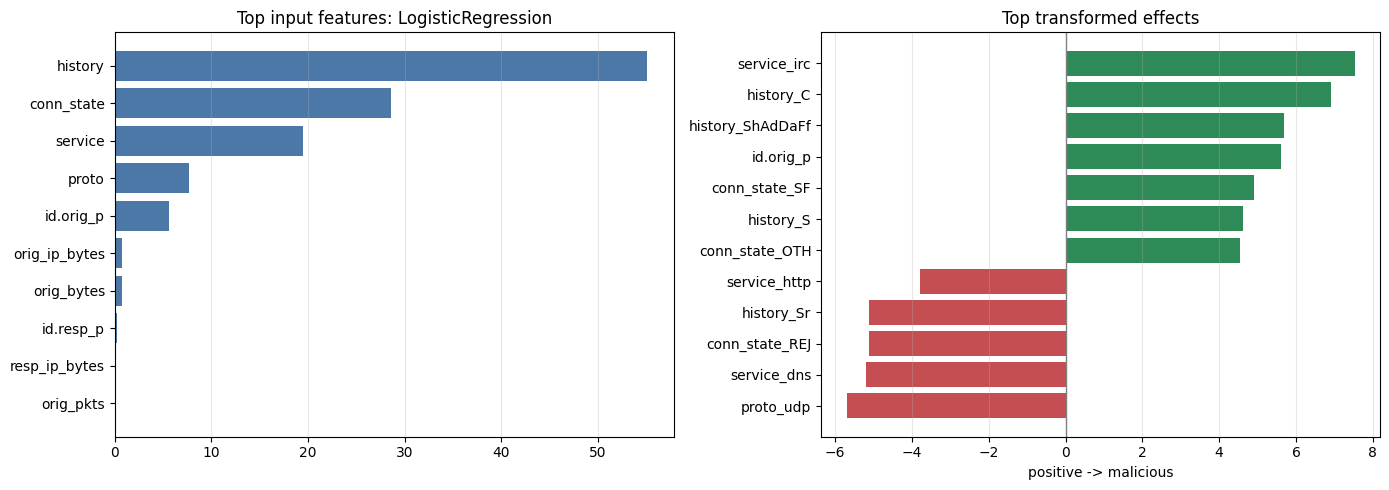

Feature contribution by input feature


,input_feature,importance
0,history,55.074967
1,conn_state,28.538359
2,service,19.531903
3,proto,7.718449
4,id.orig_p,5.617546
5,orig_ip_bytes,0.722345
6,orig_bytes,0.707496
7,id.resp_p,0.259161
8,resp_ip_bytes,0.107354
9,orig_pkts,0.081130


Top transformed features


,feature,importance,weight,direction
0,service_irc,7.524912,7.524912,malicious
1,history_C,6.903488,6.903488,malicious
2,proto_udp,5.700561,-5.700561,benign
3,history_ShAdDaFf,5.675374,5.675374,malicious
4,id.orig_p,5.617546,5.617546,malicious
5,service_dns,5.193239,-5.193239,benign
6,conn_state_REJ,5.127001,-5.127001,benign
7,history_Sr,5.124118,-5.124118,benign
8,conn_state_SF,4.895493,4.895493,malicious
9,history_S,4.623099,4.623099,malicious


/content/drive/MyDrive/flow_guard/iot23_data/feature_groups.csv
/content/drive/MyDrive/flow_guard/iot23_data/feature_effects.csv


In [20]:
model_map = {
    "LogisticRegression": lr,
    "LinearSVM": svm,
    "RandomForest": rf,
}
selected_model = model_map.get(best_model)

if selected_model is None:
    print("Feature contribution is not available for ZeroR.")
else:
    feature_names = (
        pd.Index(preprocessor.get_feature_names_out())
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
    )

    is_linear = hasattr(selected_model, "coef_")

    if is_linear:
        feature_detail = pd.DataFrame(
            {
                "feature": feature_names,
                "weight": selected_model.coef_[0],
            }
        )
        feature_detail["importance"] = feature_detail["weight"].abs()
        feature_detail["direction"] = np.where(
            feature_detail["weight"] >= 0,
            selected_model.classes_[1],
            selected_model.classes_[0],
        )
    else:
        feature_detail = pd.DataFrame(
            {
                "feature": feature_names,
                "importance": selected_model.feature_importances_,
            }
        )

    def input_feature(name):
        return next((col for col in cat_cols if name.startswith(f"{col}_")), name)

    feature_detail = feature_detail.sort_values("importance", ascending=False).reset_index(drop=True)
    feature_groups = (
        feature_detail.assign(input_feature=feature_detail["feature"].map(input_feature))
        .groupby("input_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_groups = feature_groups.head(10).sort_values("importance")
    axes[0].barh(top_groups["input_feature"], top_groups["importance"], color="#4C78A8")
    axes[0].set_title(f"Top input features: {best_model}")
    axes[0].grid(axis="x", alpha=0.3)

    if is_linear:
        top_effects = feature_detail.head(12).sort_values("weight")
        colors = np.where(top_effects["weight"] >= 0, "#2E8B57", "#C44E52")
        axes[1].barh(top_effects["feature"], top_effects["weight"], color=colors)
        axes[1].axvline(0, color="gray", linewidth=1)
        axes[1].set_xlabel(f"positive -> {selected_model.classes_[1]}")
        axes[1].set_title("Top transformed effects")
    else:
        top_effects = feature_detail.head(12).sort_values("importance")
        axes[1].barh(top_effects["feature"], top_effects["importance"], color="#F58518")
        axes[1].set_title("Top transformed features")

    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    feature_groups.to_csv(OUT_DIR / "feature_groups.csv", index=False)
    feature_detail.to_csv(OUT_DIR / "feature_effects.csv", index=False)

    print("Feature contribution by input feature")
    display(feature_groups.head(10))

    print("Top transformed features")
    display(feature_detail[[c for c in ["feature", "importance", "weight", "direction"] if c in feature_detail.columns]].head(15))

    print(OUT_DIR / "feature_groups.csv")
    print(OUT_DIR / "feature_effects.csv")
